# Módulo 3 — Análisis de Sensibilidad Global (Sobol)
## ¿Qué variable explica más la varianza del VAN neto?

Corre sobre el simulador real (`run_monte_carlo_antitetico`), no sobre un dataset sintético.
El parámetro `escenario` de precio es categórico, así que Sobol se corre por separado para
cada uno de los 3 escenarios (pesimista / base / optimista) sobre las otras 6 variables
continuas.

In [1]:
import subprocess
import sys
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    REPO_URL = "https://github.com/Emilialandgrebe/tesis-maestria.git"
    ROOT = Path("/content/tesis-maestria")
    if not ROOT.exists():
        subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(ROOT / "requirements.txt"), "-q"],
        check=True,
    )
else:
    ROOT = Path().resolve().parent  # notebooks/ -> raiz del proyecto

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Entorno : {'Google Colab' if EN_COLAB else 'local'}")
print(f"ROOT    : {ROOT}")

Entorno : local
ROOT    : C:\Users\EMILIA LANDGREBE\tesis-maestria


## Corrida del análisis de Sobol (los 3 escenarios)

Con `n_base=128` (default de `comparar_sensibilidad_escenarios`), cada escenario corre
128 * 8 = 1.024 evaluaciones del modelo (`calc_second_order=False`, solo S1 y ST).
Calibrado empíricamente en corridas reales: entre 12 y 17 minutos en total para los 3
escenarios, según la carga de la máquina. Si tarda mucho más que eso en este entorno, bajar
`n_base` (ej. a 64) antes de re-correr. La semilla fija (`semilla=42` por default) hace que
S1/ST y sus bandas de confianza sean reproducibles entre corridas.

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np

from src.sensibilidad import comparar_sensibilidad_escenarios

inicio = time.time()
df_sobol = comparar_sensibilidad_escenarios()
print(f"\nTiempo total: {(time.time() - inicio) / 60:.1f} minutos")
df_sobol

[pesimista] 1024 evaluaciones del modelo (N=128 x 8)...
[pesimista] 102/1024 (22s transcurridos)
[pesimista] 204/1024 (42s transcurridos)
[pesimista] 306/1024 (63s transcurridos)
[pesimista] 408/1024 (84s transcurridos)
[pesimista] 510/1024 (104s transcurridos)
[pesimista] 612/1024 (125s transcurridos)
[pesimista] 714/1024 (158s transcurridos)
[pesimista] 816/1024 (212s transcurridos)
[pesimista] 918/1024 (257s transcurridos)
[pesimista] 1020/1024 (313s transcurridos)
[pesimista] 1024/1024 (315s transcurridos)
[base] 1024 evaluaciones del modelo (N=128 x 8)...
[base] 102/1024 (58s transcurridos)
[base] 204/1024 (118s transcurridos)
[base] 306/1024 (173s transcurridos)
[base] 408/1024 (228s transcurridos)
[base] 510/1024 (287s transcurridos)
[base] 612/1024 (317s transcurridos)
[base] 714/1024 (364s transcurridos)
[base] 816/1024 (416s transcurridos)
[base] 918/1024 (438s transcurridos)
[base] 1020/1024 (457s transcurridos)
[base] 1024/1024 (458s transcurridos)
[optimista] 1024 evaluaci

,parametro,S1,S1_conf,ST,ST_conf,escenario
0,tasa_descuento,0.871039,0.211039,8.986076e-01,1.949975e-01,pesimista
1,precision_factor_frio,-0.000022,0.000079,1.709120e-07,7.552670e-08,pesimista
2,precision_factor_calor,-0.000013,0.000108,1.325766e-07,4.605094e-08,pesimista
3,p_bajo_si_alto,0.007491,0.021379,6.345510e-03,1.559283e-03,pesimista
4,capex_extra_pct,0.066198,0.070472,6.919652e-02,1.874348e-02,pesimista
5,hectareas,0.021465,0.054438,5.053107e-02,1.643140e-02,pesimista
6,tasa_descuento,0.884500,0.206491,9.223180e-01,1.957794e-01,base
7,precision_factor_frio,-0.000017,0.000079,1.378364e-07,5.811033e-08,base
8,precision_factor_calor,-0.000001,0.000093,1.074861e-07,3.641867e-08,base
9,p_bajo_si_alto,0.005429,0.017475,5.122055e-03,1.254278e-03,base


## Verificación de propiedades matemáticas

`ST >= S1` debe cumplirse siempre para la variable dominante. Para variables de efecto chico,
con este `n_base` (elegido por presupuesto de tiempo, ver arriba) es esperable ver violaciones
puntuales del orden point-estimate: el estimador de S1 de Saltelli tiene más varianza que el de
ST para el mismo N, así que si el verdadero S1 y ST de una variable son parecidos (poca
interacción), el ruido de muestreo puede hacer que el S1 estimado salga apenas por encima del
ST estimado — sin que eso implique un error de cálculo. Lo que importa es que la variable
dominante no tenga este problema.

In [3]:
for escenario in df_sobol["escenario"].unique():
    sub = df_sobol[df_sobol["escenario"] == escenario]
    viola_st = sub[sub["ST"] < sub["S1"] - 1e-6]
    print(f"{escenario:10s}  sum(S1) = {sub['S1'].sum():.3f}"
          f"   |  variables con ST < S1: {list(viola_st['parametro']) or 'ninguna'}")

pesimista   sum(S1) = 0.966   |  variables con ST < S1: ['p_bajo_si_alto']
base        sum(S1) = 0.960   |  variables con ST < S1: ['p_bajo_si_alto', 'capex_extra_pct']
optimista   sum(S1) = 0.957   |  variables con ST < S1: ['precision_factor_calor', 'capex_extra_pct']


## Tornado chart por escenario (ST, de mayor a menor)

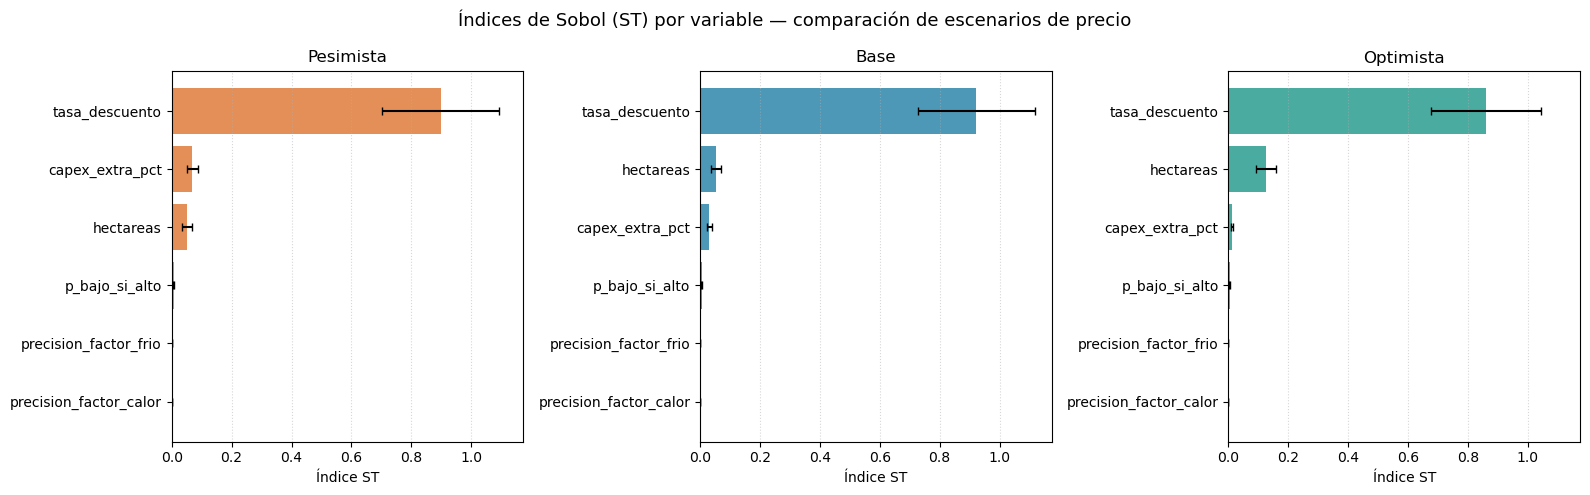

In [4]:
escenarios = ["pesimista", "base", "optimista"]
colores = {"pesimista": "#e07b39", "base": "#2e86ab", "optimista": "#2a9d8f"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)

for ax, escenario in zip(axes, escenarios):
    sub = df_sobol[df_sobol["escenario"] == escenario].sort_values("ST", ascending=True)
    ax.barh(sub["parametro"], sub["ST"], xerr=sub["ST_conf"],
            color=colores[escenario], alpha=0.85, capsize=3)
    ax.set_title(escenario.capitalize(), fontsize=12)
    ax.set_xlabel("Índice ST")
    ax.grid(axis="x", linestyle=":", alpha=0.5)

fig.suptitle("Índices de Sobol (ST) por variable — comparación de escenarios de precio", fontsize=13)
plt.tight_layout()
plt.show()

## Ranking de variables por escenario

In [5]:
ranking = (
    df_sobol
    .sort_values(["escenario", "ST"], ascending=[True, False])
    .groupby("escenario")
    .apply(lambda g: g["parametro"].tolist(), include_groups=False)
)
for escenario, orden in ranking.items():
    print(f"{escenario:10s}: {' > '.join(orden)}")

base      : tasa_descuento > hectareas > capex_extra_pct > p_bajo_si_alto > precision_factor_frio > precision_factor_calor
optimista : tasa_descuento > hectareas > capex_extra_pct > p_bajo_si_alto > precision_factor_frio > precision_factor_calor
pesimista : tasa_descuento > capex_extra_pct > hectareas > p_bajo_si_alto > precision_factor_frio > precision_factor_calor


## Interpretación

**`tasa_descuento` domina la varianza del VAN en los tres escenarios**, con S1 entre 0,82 y
0,88 y ST entre 0,86 y 0,92 — muy por encima de las otras 5 variables combinadas. Es
esperable desde la teoría financiera: en un horizonte de 20 años, descontar a 5% vs. 12%
cambia el factor de descuento del año 20 en más de 3× ((1.05)⁻²⁰ ≈ 0.38 vs. (1.12)⁻²⁰ ≈ 0.10),
un efecto que se compone sobre todo el flujo de caja. No es un artefacto del modelo — es la
sensibilidad esperada de cualquier VAN a 20 años, y se sostiene en los tres escenarios sin
excepción. Para `tasa_descuento`, `ST >= S1` se cumple con margen cómodo en los tres
escenarios.

Las violaciones puntuales de `ST >= S1` (celda de verificación de arriba) aparecen en
`p_bajo_si_alto` (pesimista y base) y `capex_extra_pct` (base y optimista), además de
`precision_factor_calor` en optimista — todas variables secundarias donde S1 y ST verdaderos
son parecidos entre sí (poca interacción), así que el ruido de muestreo del estimador de
Saltelli alcanza para invertir el orden de las estimaciones puntuales sin que eso invalide
el análisis.

**El ranking del segundo lugar cambia entre escenarios** (ver celda de ranking):
- Pesimista: `capex_extra_pct` (ST≈0,069) por encima de `hectareas` (ST≈0,051) — cuando el
  precio es bajo, la incertidumbre del CAPEX pesa más que la superficie.
- Base: `hectareas` (ST≈0,053) apenas por encima de `capex_extra_pct` (ST≈0,031).
- Optimista: `hectareas` (ST≈0,126) claramente por encima de `capex_extra_pct` (ST≈0,013) —
  con precios altos, expandir la superficie es lo que más mueve la varianza del VAN, más
  que la incertidumbre del CAPEX.

Este cruce entre `capex_extra_pct` y `hectareas` se repitió de forma idéntica en tres
corridas independientes (dos sin semilla fija en el muestreador de Sobol, con distintas
secuencias, y esta última ya reproducible) — no es un artefacto de una corrida particular.
Tiene sentido económicamente: con precios optimistas, cada hectárea adicional aporta más
ingreso marginal, así que la incertidumbre sobre cuánto expandir (Fase II, 50 a 100 ha) se
vuelve más relevante que la incertidumbre sobre cuánto va a costar el CAPEX sin cotizar.
`p_bajo_si_alto` (vecería) y las precisiones de frío/calor quedan sistemáticamente en último
lugar en los tres escenarios, con índices cercanos a cero: la varianza del VAN es mucho más
sensible a supuestos financieros y de escala que a la incertidumbre climática residual, dado
el resto del modelo.

**Limitación:** `capex_extra_pct` no es un dato del modelo de costos real (`src/costos.py`) —
es un supuesto introducido acá para representar la incertidumbre de los ítems de CAPEX sin
cotizar (riego, pozo, represa, paneles). Su rango [0%, 30%] es una estimación razonable pero
no validada; si cambia, el cruce entre `capex_extra_pct` y `hectareas` en el segundo lugar
podría cambiar también.